In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [78]:
image = cv2.imread('sar_2.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

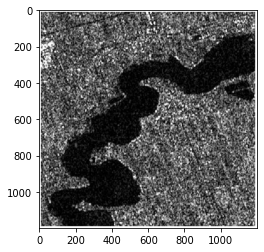

In [5]:
plt.imshow(image_gray, cmap="gray")

# Точечная бинаризация

In [52]:
import copy

bin_img = copy.deepcopy(image_gray)
T  = 50
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255

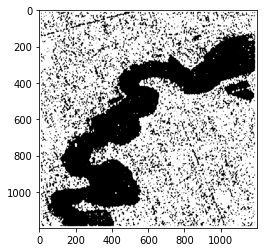

In [53]:
plt.imshow(bin_img, cmap="gray")

# Бинаризация Отсу

In [7]:
# otsu binarization
_,th2 = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

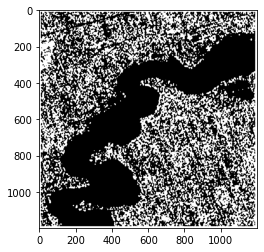

In [8]:
plt.imshow(th2, cmap="gray")

# Адаптивная бинаризация

In [42]:
# 
th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,71,21)


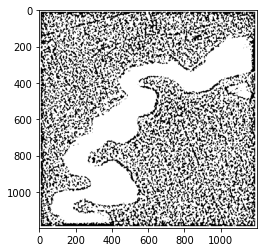

In [43]:
plt.imshow(th3, cmap="gray")

# Оператор Собеля

In [55]:
scale = 1
delta = 0
ddepth = cv2.CV_16S
grad_x = cv2.Sobel(image_gray, ddepth, 1, 0, ksize=3, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)
grad_y = cv2.Sobel(image_gray, ddepth, 0, 1, ksize=3, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)

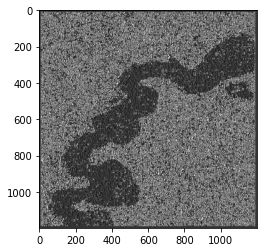

In [57]:
plt.imshow((grad_x - grad_x.min())*255, cmap="gray")

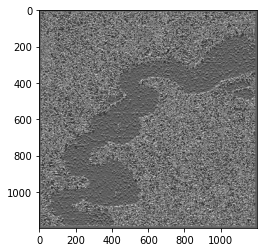

In [58]:
plt.imshow((grad_y - grad_y.min())*255, cmap="gray")

In [60]:
grad = cv2.addWeighted(grad_x, 0.5, grad_y, 0.5,0.0) # mean value between

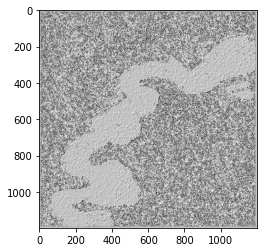

In [62]:
plt.imshow((grad - grad.min())*255, cmap="gray")

# Canny

In [64]:
edges = cv2.Canny(image_gray,100,200)

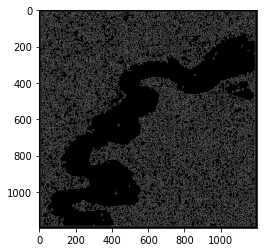

In [65]:
plt.imshow(edges, cmap="gray")

# Преобразование Хафа

In [127]:
image = cv2.imread('img_1.jpg')
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) 
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

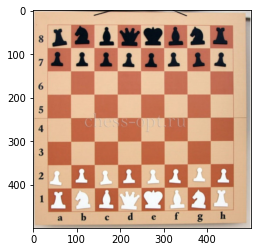

In [128]:
plt.imshow(image)

In [138]:
canny = cv2.Canny(image_gray,50,150,apertureSize = 3)

In [146]:
lines = cv2.HoughLines(canny, 1, np.pi / 180, 190)

In [147]:
import math 

if lines is not None:
        for i in range(0, len(lines)):
            rho = lines[i][0][0]
            theta = lines[i][0][1]
            a = math.cos(theta)
            b = math.sin(theta)
            x0 = a * rho
            y0 = b * rho
            pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
            pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
            cv2.line(image, pt1, pt2, (0,0,255), 3, cv2.LINE_AA)

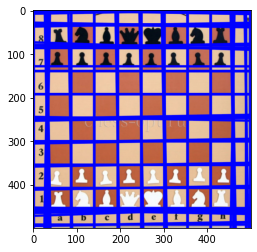

In [148]:
plt.imshow(image)

In [149]:
#ДЗ 
# 1. Для изображения sar_3.jpg найти наиболее протяженный участок
# (выделить линии при помощи преобразования Хафа)
# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

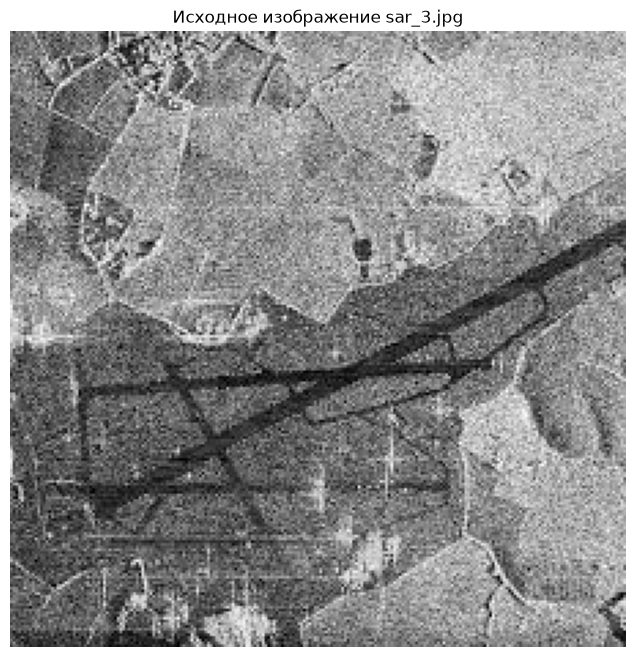

In [2]:
image_sar3 = cv2.imread('sar_3.jpg')
image_sar3_gray = cv2.cvtColor(image_sar3, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 8))
plt.imshow(image_sar3_gray, cmap='gray')
plt.title('Исходное изображение sar_3.jpg')
plt.axis('off')
plt.show()

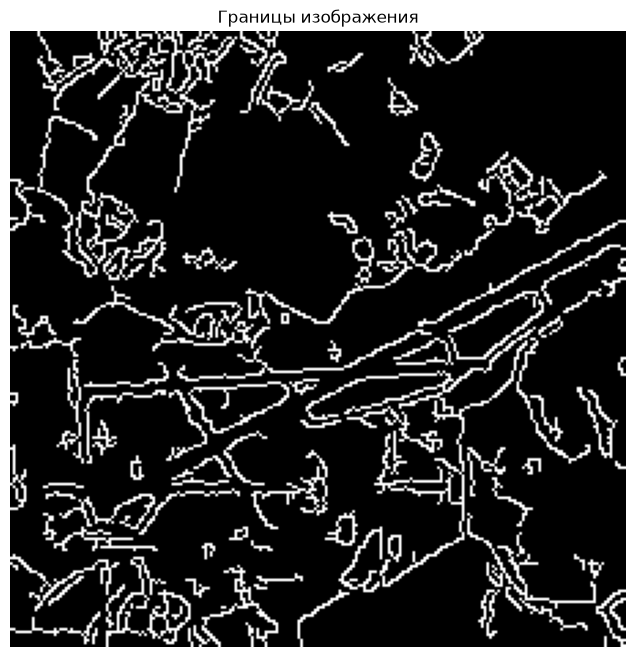

In [5]:
blurred = cv2.GaussianBlur(image_sar3_gray, (5, 5), 0)

edges = cv2.Canny(blurred, 80, 180)

plt.figure(figsize=(8, 8))
plt.imshow(edges, cmap='gray')
plt.title('Границы изображения')
plt.axis('off')
plt.show()

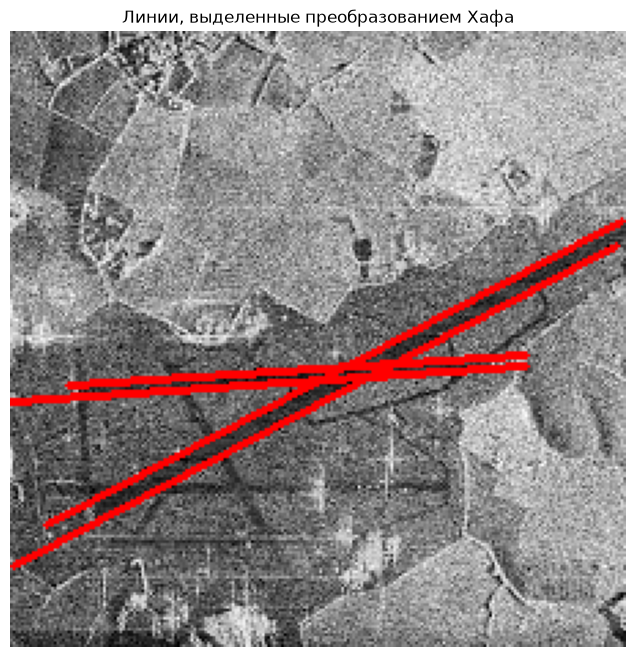

In [6]:
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=80,
    minLineLength=80,
    maxLineGap=20
)

image_lines = image_sar3.copy()

if lines is not None:
    for line in lines.reshape(-1, 4):
        x1, y1, x2, y2 = line
        cv2.line(image_lines, (x1, y1), (x2, y2), (0, 0, 255), 2)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(image_lines, cv2.COLOR_BGR2RGB))
plt.title('Линии, выделенные преобразованием Хафа')
plt.axis('off')
plt.show()

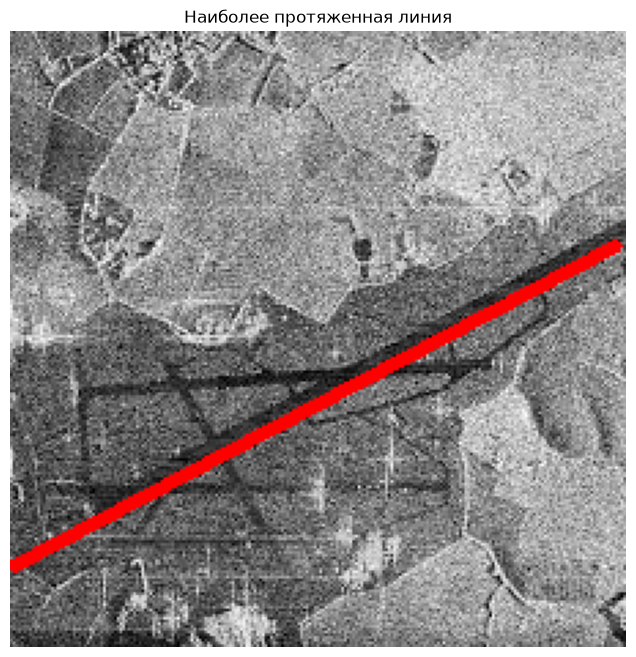

In [7]:
max_length = 0
longest_line = None

for x1, y1, x2, y2 in lines.reshape(-1, 4):
    length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

    if length > max_length:
        max_length = length
        longest_line = (x1, y1, x2, y2)

result = image_sar3.copy()

if longest_line is not None:
    x1, y1, x2, y2 = longest_line
    cv2.line(result, (x1, y1), (x2, y2), (0, 0, 255), 3)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title('Наиболее протяженная линия')
plt.axis('off')
plt.show()

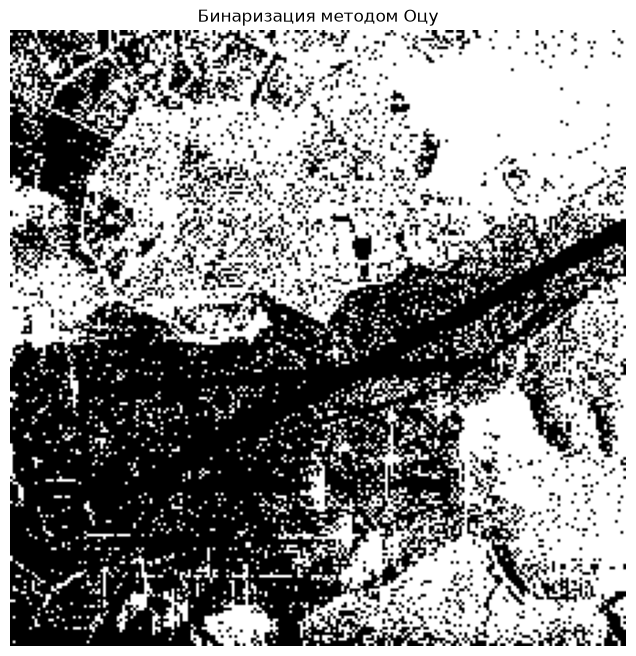

In [8]:
_, binary_otsu = cv2.threshold(
    image_sar3_gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(8, 8))
plt.imshow(binary_otsu, cmap='gray')
plt.title('Бинаризация методом Оцу')
plt.axis('off')
plt.show()

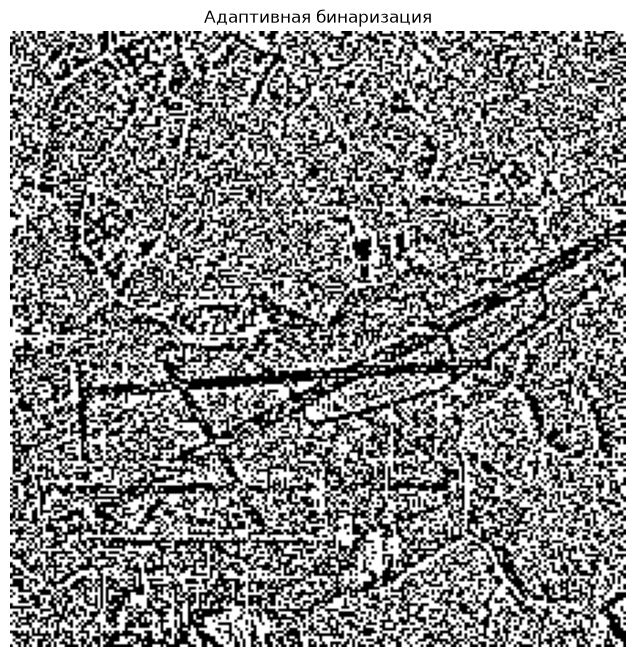

In [9]:
binary_adaptive = cv2.adaptiveThreshold(
    image_sar3_gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

plt.figure(figsize=(8, 8))
plt.imshow(binary_adaptive, cmap='gray')
plt.title('Адаптивная бинаризация')
plt.axis('off')
plt.show()

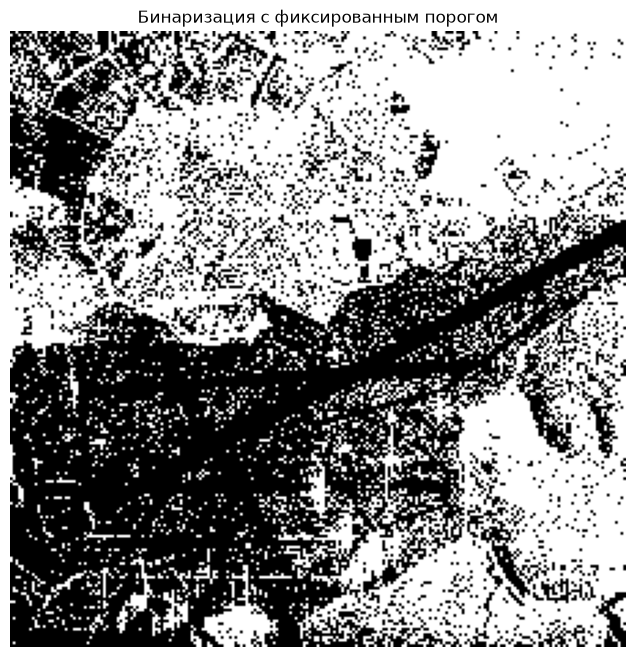

In [10]:
_, binary_simple = cv2.threshold(
    image_sar3_gray,
    127,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(8, 8))
plt.imshow(binary_simple, cmap='gray')
plt.title('Бинаризация с фиксированным порогом')
plt.axis('off')
plt.show()

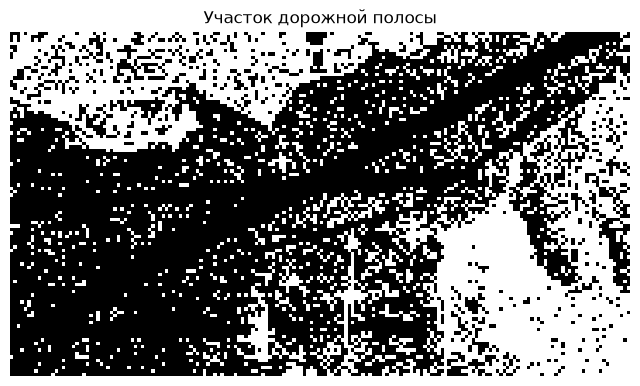

In [16]:
road_section = binary_otsu[80:180, 40:220]

plt.figure(figsize=(8, 5))
plt.imshow(road_section, cmap='gray')
plt.title('Участок дорожной полосы')
plt.axis('off')
plt.show()